# Nowcasting Autoencoder Tutorial

Creating an effective autoencoder is a great first step in developing a predictive model. Learning how to create a high-quality latent state is critical, and can later be used to train a new encoder for a pre-existing predictive model, or a new decoder. An example for this could be training an encoder which uses different or fewer variables than the original model. Another might be training a higher-resolution decoder which is capable of producing higher-resolution predictions from the same latent state.

Autoencoders are also a great concept to learn when understanding neural network architectures.

In this example, we first blend radar and satellite data onto the same grid, then train an autoencoder to perform dimensionality reduction and produce a useful latent state which can be used to resonstruct the original inputs.

In [1]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

from pyearthtools.data import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge

import xarray as xr

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt


# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
rf3proj = petdata.transforms.projection.Rainfields3ProjAus()
radar_projector = petdata.transforms.projection.XYtoLonLatRectilinear(rf3proj)

In [3]:
# We specify the date, hour, and minute for querying data
doi = '2021-06-09T02'

In [4]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

In [5]:
# TODO: It would be nice if this normalised the data nicely
satpipe = petpipe.Pipeline(
    himawari
)

In [6]:
himawari_sample = satpipe[doi]
himawari_sample

/g/data/kd24/tjl/src/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:329: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  full_ds = xr.open_mfdataset(


<xarray.Dataset> Size: 183MB
Dimensions:                    (time: 6, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 48B 2021-06-09T02:00:00 ...
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/50)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    geospatial_lon_resolution:        0.02
    bias_correction_applied_meaning:  0: not applied; 1:applied
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [7]:
radar = petdata.archive.Rainfields3(variables='prcp-crate')

In [8]:
radarpipe = petpipe.Pipeline(
    radar,
    radar_projector,
    petpipe.operations.xarray.metadata.Rename({'valid_time':'time'}),
)

In [9]:
prepare = petpipe.Pipeline(
    (satpipe, radarpipe),
    GeospatialTimeSeriesMerge(reference_dataset=himawari_sample), # These are pretty similar grids, so just pick one
    iterator=petpipe.iterators.DateRange(2021, 2023, interval='20 minutes')
)
prepare

ipipe = iter(prepare)  # Make an iterator to walk the time period

In [10]:
%%time

# Takes around 15 seconds per sample to retrieve, largely due to the zip compression used on-disk
merged_sample = next(ipipe)
merged_sample

CPU times: user 12.7 s, sys: 2.5 s, total: 15.3 s
Wall time: 15.3 s


<xarray.Dataset> Size: 245MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214, n2: 2)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-01-01
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
    x                          (longitude, latitude) float64 31MB -1.651e+03 ...
    y                          (longitude, latitude) float64 31MB -4.99e+03 ....
Dimensions without coordinates: n2
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
    proj                       (time) int8 1B 0
    y_bounds                   (time, longitude, latitude, n2) float64 61MB -...
    x_bounds                   (time, longitude, latitude, n2) float64 61MB -...
    rain_rate                  (time, longitude, latitude) float64 31MB nan ....
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:23 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [11]:
full = petpipe.Pipeline(
    (satpipe, radarpipe),
    GeospatialTimeSeriesMerge(reference_dataset=himawari_sample), # These are pretty similar grids, so just pick one
    petdata.transforms.variables.Drop(['x_bounds', 'y_bounds', 'proj', 'x', 'y']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  # Align data variables coordinate ordering to dataset coordinate ordering
    petdata.transform.region.Bounding(-40, -25, 135, 152),  # cut down on region for example
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20200101T00', '20210101T00', interval='20 minutes')
)
full

ipipe = iter(full)  # Make an iterator to walk the time period

In [12]:
fullsat = petpipe.Pipeline(
    satpipe,
    # GeospatialTimeSeriesMerge(reference_dataset=himawari_sample), # These are pretty similar grids, so just pick one
    # petdata.transforms.variables.Drop(['x_bounds', 'y_bounds', 'proj', 'x', 'y']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20200101T00', '20210101T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)
fullsat

ipipe = iter(fullsat)  # Make an iterator to walk the time period

In [13]:
fullsat.exceptions_to_ignore

(pyearthtools.data.exceptions.DataNotFoundError,)

In [14]:
n = next(ipipe)
# n

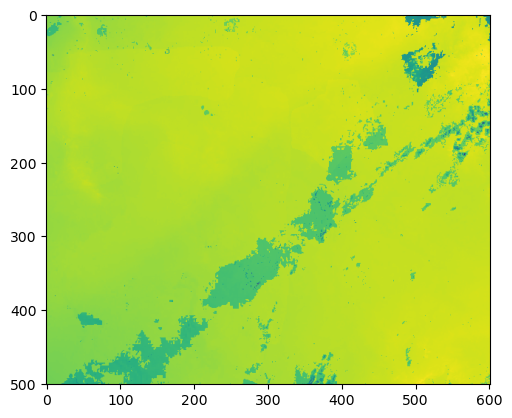

In [15]:
plt.imshow(n[0][0])

In [16]:
# Here we define an "AutoEncoder". This is a model which reproduces its inputs, 
# through a bottleneck layer. It is one of the primary concepts behind many 
# neural network architectures that you will work with in future, and is key to
# conceptual understanding as well as being sometimes useful in 

# Reminder, the image size is latitude: 1726, longitude: 2214

class AutoEncoder(nn.Module):
    def __init__(self, 
                 input_height = 501,
                 input_width = 601,
                 kernel_size = 4,
                 stride=2,
                 input_channel_count = 2,
                 output_channel_count = 2,
                 latent_dim=300):
        super(AutoEncoder, self).__init__()

        self.input_width = input_width
        self.input_height = input_height
        self.input_channel_count = input_channel_count
        self.output_channel_count = output_channel_count

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=self.input_channel_count, out_channels=16, kernel_size=kernel_size, stride = stride, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride =2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=self.output_channel_count, kernel_size=kernel_size, stride=stride, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, x):

        # Get latent representation
        latent = self.encoder(x)

        # Reconstruct input
        reconstructed = self.decoder(latent)

        return reconstructed

In [17]:
# Initialize model and move to device
model = AutoEncoder(input_channel_count=1, output_channel_count=1).to(device)

# Loss function and optimizer
criterion = nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [18]:
x = torch.from_numpy(n).float().to(device)

In [19]:
# This should make us a messy prediction from an untrained model in the dimension of the input
prediction = model.forward(x)

In [20]:
image_numpy_for_display = prediction.to('cpu').detach().numpy()
# image_numpy_for_display

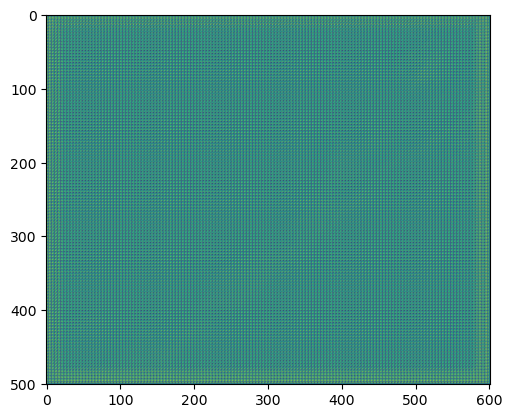

In [21]:
plt.imshow(image_numpy_for_display[0][0])

In [22]:
%%time

# 1000 samples is taking about 2 minutes
# It should be able to go much much much faster, but still we can test it and make progress
# Let's to 30 minutes of training, i.e. 15k samples

def train(debug=True, num_epochs=1, max_samples=10, print_per=20):
    # Training loop
    
    sample_ix = 0 
    
    
    for epoch in range(num_epochs):
        total_loss = 0    
        epoch_samples = 0
        ipipe = iter(fullsat)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(ipipe)
            except StopIteration:
                break  # advance the epoch loop
            except:
                pass # some samples are just missing
    
            sample_ix += 1
            epoch_samples += 1
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   

            if torch.any(torch.isnan(x)):
                # Skip nan inputs, they break the training
                continue
                
            if debug:
                print("Input")
                print(x)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model.forward(x)

            if debug:
                print("prediction")
                print(y)
            
            loss = criterion(y, x)
            if debug:
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        avg_loss = total_loss / epoch_samples
        epoch_samples = 0  # Reset for next epoch
        print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')

train(debug=False, num_epochs=1, max_samples=15 * 1000, print_per = 500)

500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
10500
11000
11500
12000
12500
13000
13500
14000
14500
15000
Epoch [1/0], Average Loss: 0.0375
CPU times: user 27min 36s, sys: 4min 24s, total: 32min 1s
Wall time: 42min 37s


In [23]:
x.min()

tensor(0.2183, device='cuda:0')

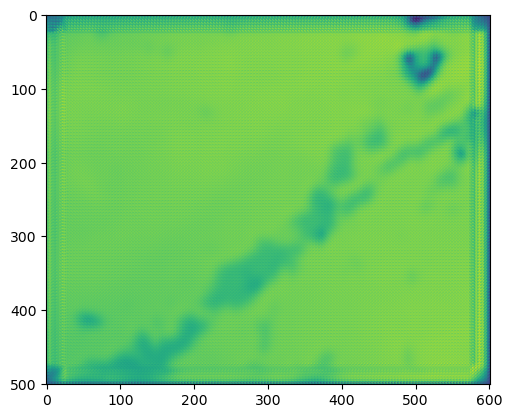

In [24]:
prediction = model.forward(x)
image_numpy_for_display = prediction.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])

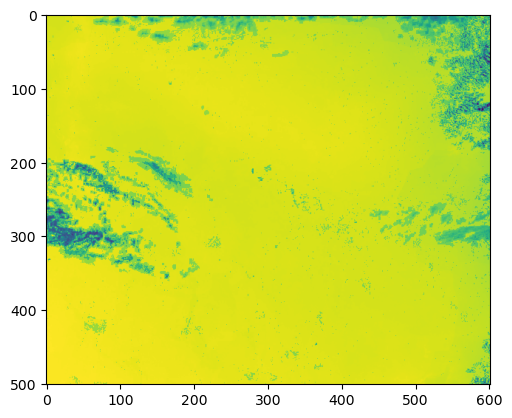

In [25]:


z = torch.from_numpy(fullsat['20210303T0400']).float().to(device)

image_numpy_for_display = z.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])

In [26]:
latent = model.encoder(z)

In [27]:
latent.shape

torch.Size([1, 64, 119, 144])

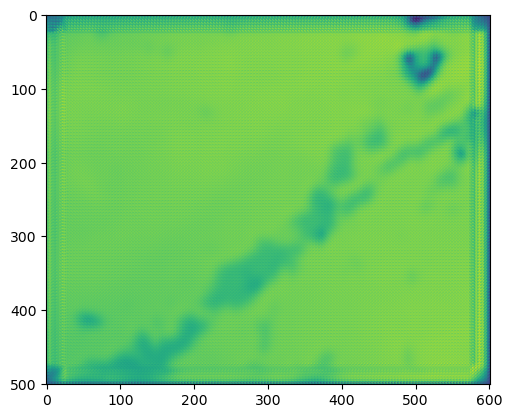

In [28]:
reconstruction = model.forward(z)
image_numpy_for_display = prediction.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])